In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib 

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
df.nunique()

id                                48895
name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

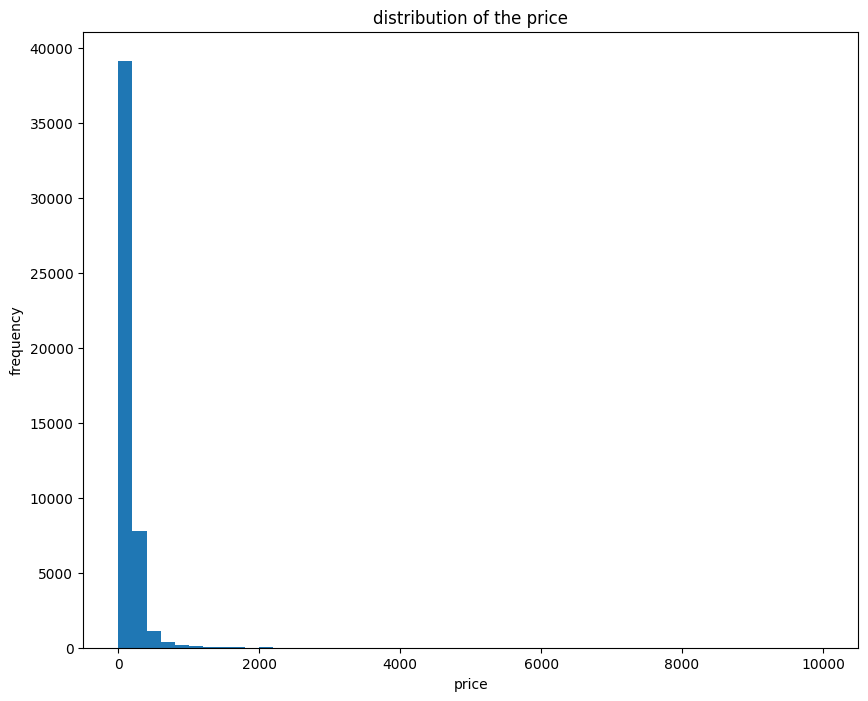

In [11]:
plt.figure(figsize=(10,8))
plt.hist(df["price"], bins=50)
plt.title("distribution of the price")
plt.xlabel("price")
plt.ylabel("frequency")
plt.show()

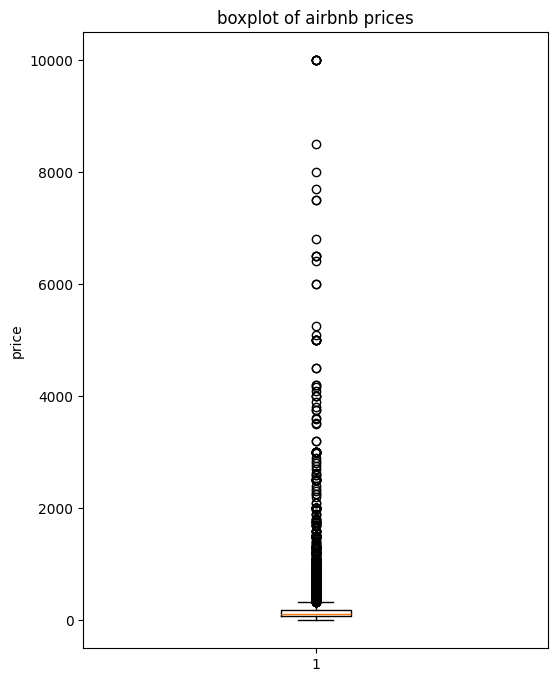

In [12]:
plt.figure(figsize=(6,8))
plt.boxplot(df["price"])
plt.title("boxplot of airbnb prices")
plt.ylabel("price")
plt.show()
           

In [13]:
df["room_type"].nunique()

3

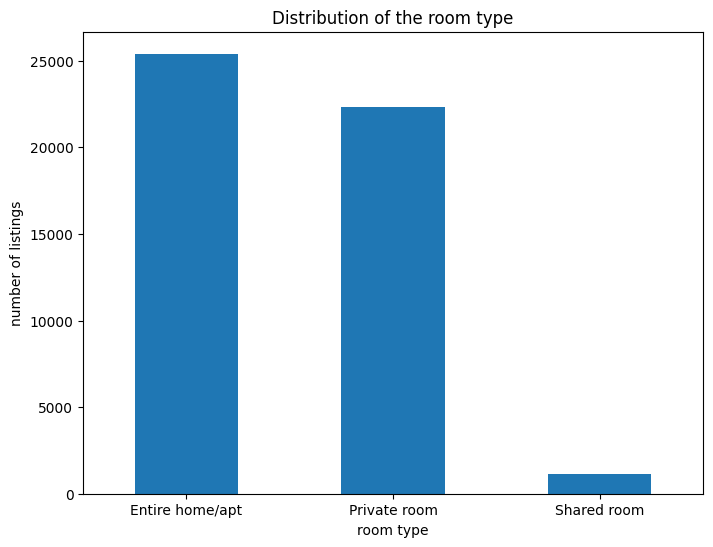

In [14]:
plt.figure(figsize=(8,6))
df["room_type"].value_counts().plot(kind="bar")
plt.title("Distribution of the room type")
plt.xlabel("room type")
plt.ylabel("number of listings")
plt.xticks(rotation=0)
plt.show()


In [15]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

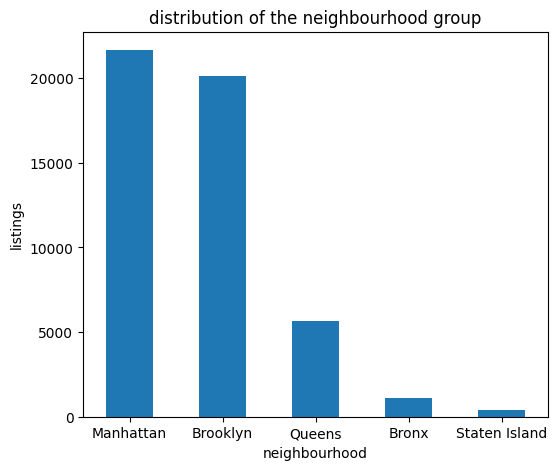

In [16]:
plt.figure(figsize=(6,5))
df["neighbourhood_group"].value_counts().plot(kind="bar")
plt.title("distribution of the neighbourhood group")
plt.xlabel("neighbourhood")
plt.ylabel("listings")
plt.xticks(rotation=0)
plt.show()


In [17]:
numeric_df = df.select_dtypes(include=["number"])

In [18]:
corr_df = numeric_df.corr()

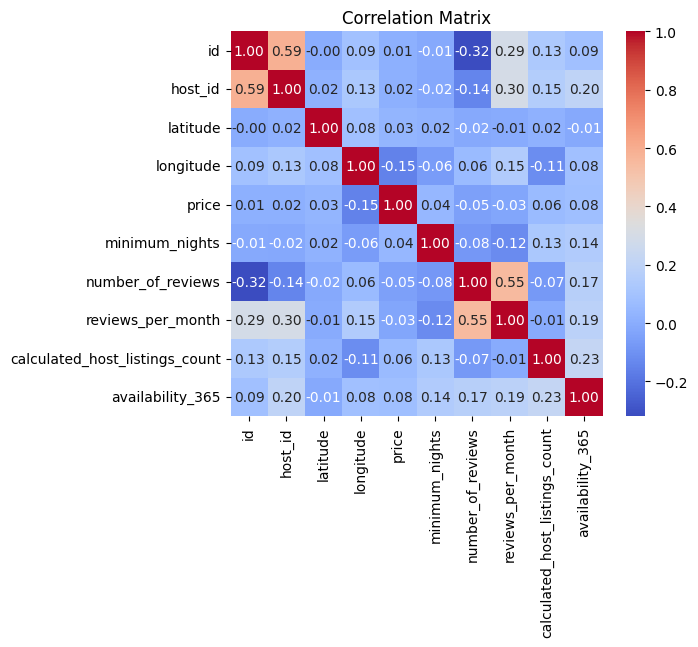

In [19]:
import seaborn as sb
plt.figure(figsize=(6,5))
sb.heatmap(corr_df, annot = True , cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [20]:
df = df.drop(columns=["id"])

In [21]:
df= df.drop(columns=["name"])

In [22]:
df= df.drop(columns=["host_id"])

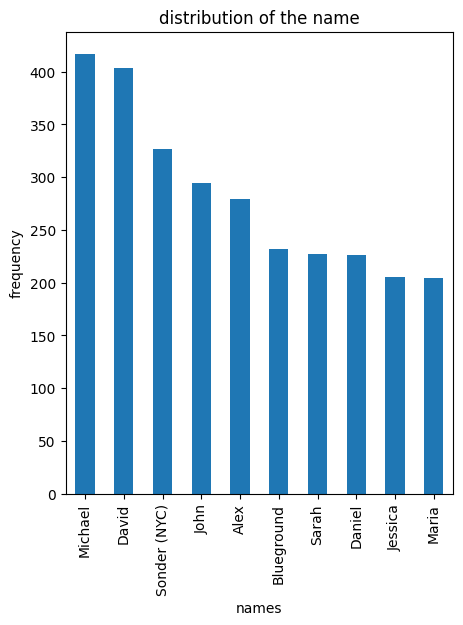

In [23]:
plt.figure(figsize=(5,6))
df["host_name"].value_counts().head(10).plot(kind="bar")
plt.xlabel("names")
plt.ylabel("frequency")
plt.title("distribution of the name")
plt.show()

In [24]:
df = df.drop(columns=["host_name"])

In [25]:
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [26]:
df["last_review"].head()

0    2018-10-19
1    2019-05-21
2           NaN
3    2019-07-05
4    2018-11-19
Name: last_review, dtype: str

In [27]:
df["last_review"]= pd.to_datetime(df["last_review"])


In [28]:
df["review_year"]= df["last_review"].dt.year 

In [29]:
df["review_month"]= df["last_review"].dt.month

In [30]:
df= df.drop(columns=["last_review"])

In [31]:
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'review_year', 'review_month'],
      dtype='str')

In [32]:
df[["review_year", "review_month"]].isnull().sum()

review_year     10052
review_month    10052
dtype: int64

In [33]:
df["reviews_per_month"].isnull().sum()

np.int64(10052)

In [34]:
df["reviews_per_month"]= df["reviews_per_month"].fillna(0)

In [35]:
df["reviews_per_month"].isnull().sum()

np.int64(0)

In [36]:
df.isnull().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
review_year                       10052
review_month                      10052
dtype: int64

In [37]:
df.dtypes 

neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
review_year                       float64
review_month                      float64
dtype: object

In [38]:
df = pd.get_dummies(df, columns=["neighbourhood_group", "neighbourhood", "room_type"], drop_first= True, dtype = int)

In [39]:
df.dtypes

latitude                  float64
longitude                 float64
price                       int64
minimum_nights              int64
number_of_reviews           int64
                           ...   
neighbourhood_Woodlawn      int64
neighbourhood_Woodrow       int64
neighbourhood_Woodside      int64
room_type_Private room      int64
room_type_Shared room       int64
Length: 236, dtype: object

In [40]:
df = df[df["price"]>0]

In [41]:
X = df.drop(columns=["price"])
y = np.log1p(df["price"])

In [42]:
X.shape

(48884, 235)

In [43]:
y.shape

(48884,)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [45]:
X_train.shape

(39107, 235)

In [46]:
X_test.shape

(9777, 235)

In [47]:
y_train.shape

(39107,)

In [48]:
y_test.shape

(9777,)

In [49]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

In [50]:
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [51]:
y_pred = model.predict(X_test)

In [52]:
y_pred_og = np.expm1(y_pred)
y_test_og = np.expm1(y_test)

In [53]:
y_pred[:10]

array([4.5936403, 4.490977 , 4.7148433, 3.9875731, 4.7286   , 4.425279 ,
       4.813909 , 4.1163263, 4.24009  , 3.9351041], dtype=float32)

In [54]:
mae = mean_absolute_error(y_test_og, y_pred_og)
print("Mean Absolute Error: ", round(mae, 2))

Mean Absolute Error:  55.68


In [55]:
mse = mean_squared_error(y_test_og, y_pred_og)
print("Mean Squared Error: ", round(mse, 2))

Mean Squared Error:  31915.72


In [56]:
rmse = np.sqrt(mse)
print("rmse :", round(rmse, 2))

rmse : 178.65


In [57]:
print(np.isinf(y_pred_og).sum())
print(np.isnan(y_pred_og).sum())

print(np.isinf(y_test_og).sum())
print(np.isnan(y_test_og).sum())

print(y_pred.max())
print(y_pred_og.max())

0
0
0
0
6.896427
987.7358


In [58]:
r2_log = r2_score(y_test, y_pred)
print("R2_score_log: ", round(r2_log, 2))

R2_score_log:  0.6


In [59]:
r2 = r2_score(y_test_og, y_pred_og)
print("R2 score: ", round(r2, 2))

R2 score:  0.2


In [60]:
df["price"].describe()

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [61]:
df["price"].skew()

np.float64(19.119026764709606)

In [62]:
(df["price"] == 0).sum()

np.int64(0)

In [63]:
print(y_train.max())
print(y_train.min())

9.210440366976517
2.3978952727983707


In [68]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
233,room_type_Private room,0.251320
10,neighbourhood_group_Manhattan,0.153402
234,room_type_Shared room,0.117267
218,neighbourhood_Washington Heights,0.048759
139,neighbourhood_Midtown,0.018660
9,neighbourhood_group_Brooklyn,0.016475
226,neighbourhood_Williamsburg,0.012503
1,longitude,0.011740
73,neighbourhood_East Harlem,0.010293
209,neighbourhood_Tribeca,0.009313


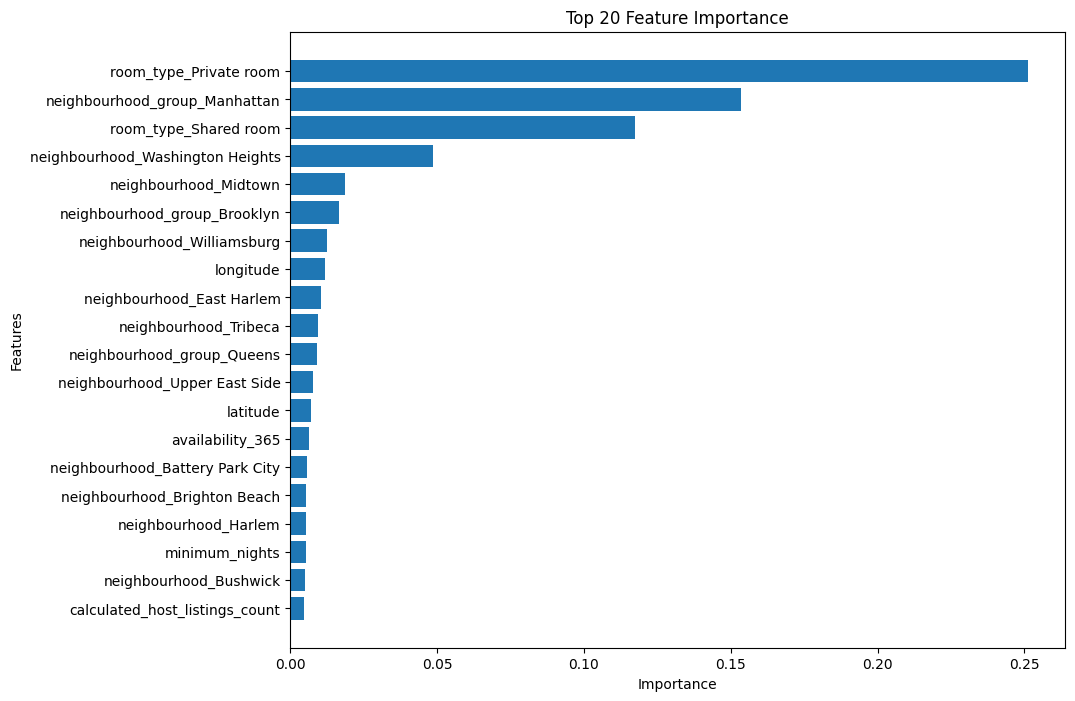

In [69]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Feature Importance")

plt.show()

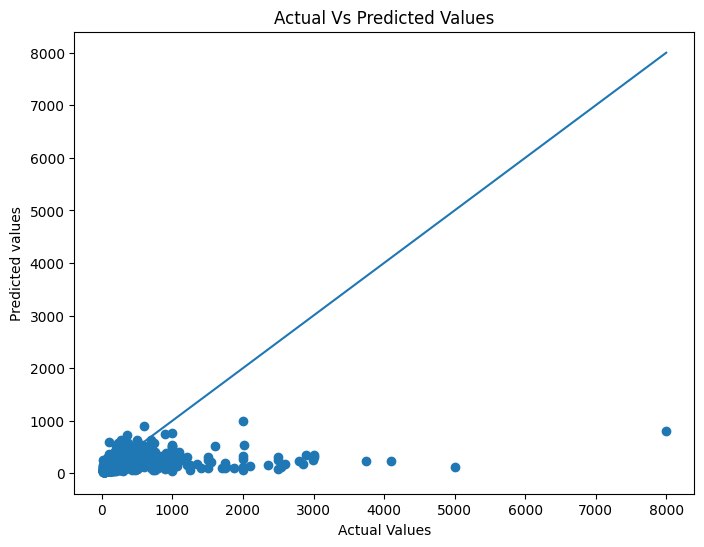

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_og, y_pred_og)
plt.plot(
    [y_test_og.min(), y_test_og.max()],
    [y_test_og.min(), y_test_og.max()]
)
plt.title("Actual Vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted values")
plt.show()

In [79]:
joblib.dump(model, "staywise_model.pkl")

['staywise_model.pkl']